In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import os, sys
sys.path.append('./bin')
from multiplesites_eqbinding_polcycle import avb_1sites, avb_2sites, avb_3sites, avb_3sites_nologsumexp,avb_4sites, avb_5sites, avb_6sites, foldchange_from_avbinding_ratesdirectly_Hill


In [3]:
def f1(x,pars):
    #single site
    k10,k20,k3,k4,Kx,s1,n1,k1sat,s2,n2,k2sat=pars
    a=Kx*x/(1+Kx*x) #equilibrium occupancy
    Hill1=(a**n1)/(s1**n1+a**n1)
    k1=k10+(k1sat-k10)*Hill1
    Hill2=(a**n2)/(s2**n2+a**n2)
    k2=k20+(k2sat-k20)*Hill2
    m=k3*(k1*k2)/(k2*k3+k3*k4+k1*k3+k1*k2)
    return [m, a, k1, k2]

def f2(x,pars):
    #single site
    k1,k20,k30,k4,Kx,s1,n1,k1sat,s2,n2,k2sat=pars
    a=Kx*x/(1+Kx*x) #equilibrium occupancy
    Hill1=(a**n1)/(s1**n1+a**n1)
    k3=k30+(k1sat-k30)*Hill1
    Hill2=(a**n2)/(s2**n2+a**n2)
    k2=k20+(k2sat-k20)*Hill2
    m=k3*(k1*k2)/(k2*k3+k3*k4+k1*k3+k1*k2)
    return [m, a, k2, k3]

def fmultiple(a,pars_noKx):
    #a is the equilibrium average binding, can be used for 1 or multiple sites
    #for more flexibility in which rates to affect, use foldchange_from_avbinding_ratesdirectly_Hill
    k10,k20,k3,k4,s1,n1,k1sat,s2,n2,k2sat=pars_noKx
    Hill1=(a**n1)/(s1**n1+a**n1)
    k1=k10+(k1sat-k10)*Hill1
    Hill2=(a**n2)/(s2**n2+a**n2)
    k2=k20+(k2sat-k20)*Hill2
    m=k3*(k1*k2)/(k2*k3+k3*k4+k1*k3+k1*k2)
    return [m, a, k1, k2]

**Plot fold change in K vs concentration space, as well as in K vs number of sites space**

In [3]:
#affinity value for plot of K vs number of sites
log_x=-1.75
print(np.exp(log_x))
np.log10(np.exp(log_x))

0.17377394345044514


-0.7600153433306907

In [4]:
avb_3sites([0.57,1,-2],2),avb_3sites_nologsumexp([0.57,1,-2],2) #show that these two functions give the same

(2.3814798227381466, 2.3814798227381466)

In [5]:
mpl.rcParams["font.size"]=10

0.005
0.8059899687817743 1.8860447845359043
0.81 1.89


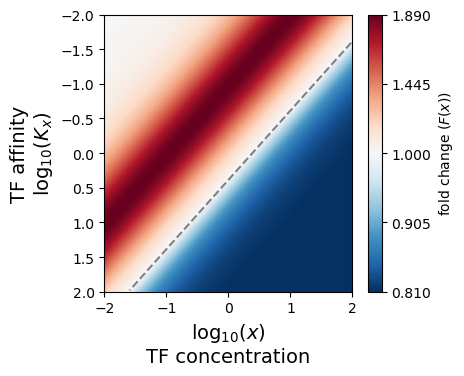

K vs sites heatmap at x=0.173774
0.25437464597812337 1.8860485682386603
0.25 1.89


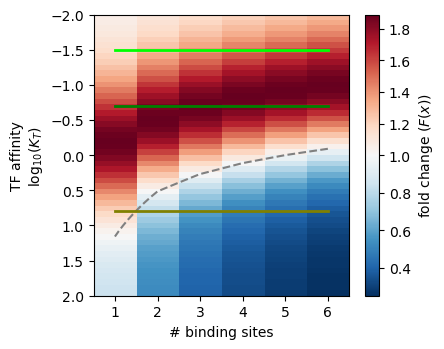

$K_T=0.03$
$K_T=0.20$
$K_T=6.31$


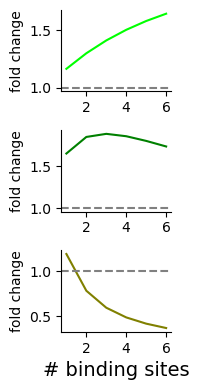

0.18491043065077215 1.3710017352006467
0.18 1.37


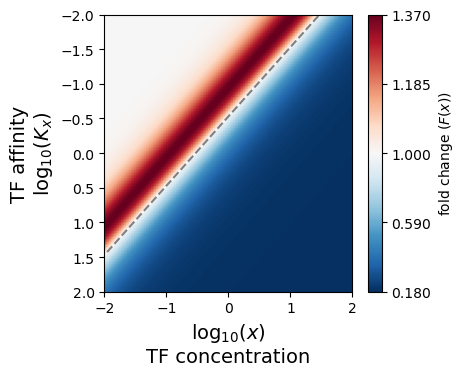

K vs sites heatmap at x=0.173774
0.09971618925517425 1.3703680072974116
0.1 1.37


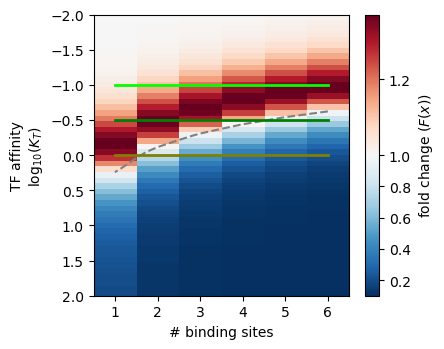

$K_T=0.10$
$K_T=0.32$
$K_T=1.00$


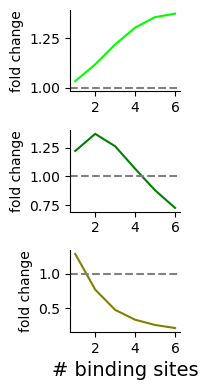

In [22]:
#define parameter set
k3=0.1
k4=50
Kx=1

k10=0.5
k1sat=k10*10
s1=0.2
n1=1

k20=0.5
k2sat=k20*0.01
print(k2sat)
s2=0.1
n2=1

log_x=-1.75
cmap=plt.cm.RdBu_r
xvals=np.logspace(-2,2,100)
Kxvals=np.logspace(-2,2,100)
functions=[avb_1sites, avb_2sites, avb_3sites, avb_4sites, avb_5sites, avb_6sites]

Klevels1=[0.8,-0.7,-1.5]
Klevels2=[0,-0.5,-1]
Klevelslist=[Klevels1,Klevels2]
colors_K=["olive","green","lime"]

for n in [1,2]: #h in the paper, hill coefficient
    Klevels=Klevelslist[n-1]
    pars=[k10,k20,k3,k4,s1,n,k1sat,s2,n,k2sat]

    m0=fmultiple(0,pars)[0] #basal expression, TF concentration=0 so average binding = 0

    

    #K vs concentration heatmap for single site
    
    out=np.zeros((len(Kxvals), len(xvals)))
    for b, Kx in enumerate(Kxvals):
        for x_,xval in enumerate(xvals):
            avb=avb_1sites([np.log(Kx)],np.log(xval))
            m=fmultiple(avb,pars)[0]
            out[b,x_]=m/m0
    min_val_rounded=np.round(out.min(),2) #round minimum value to 2 decimal
    max_val_rounded=np.round(out.max(),2) #round max value to 2 decimals
    print(out.min(),out.max())
    print(min_val_rounded, max_val_rounded)
    fig,ax=plt.subplots(1,1,figsize=(4,3*1.2)) 
    norm=mpl.colors.TwoSlopeNorm(vmin=min_val_rounded, vcenter=1., vmax=max_val_rounded)
    extent=[np.log10(xvals[0]),np.log10(xvals[-1]),np.log10(Kxvals[-1]),np.log10(Kxvals[0])]

    im=ax.imshow(out,origin="upper",norm=norm,cmap=cmap,extent=extent,aspect="auto")
    ax.contour(out,origin="upper",extent=extent,levels=[1],linestyles=["--"],colors=["gray"])

    ax.set_ylabel("TF affinity\n"+r"log$_{10}$($K_x$)",size=14)
    ax.set_xlabel(r"log$_{10}$($x$)"+"\nTF concentration",size=14)

    #colorbar bounds: below and above 1 different spacing but uniformly distributed ticks
    below_one=np.linspace(min_val_rounded,1,3)
    above_one=np.linspace(1,max_val_rounded,3)
    bounds=np.concatenate((below_one,above_one[1:]))
    cbax=plt.colorbar(im,ax=ax,ticks=bounds)
    cbax.set_label(label="fold change ($F(x)$)")

    #ax.axhline(y=1,linestyle="--",color="gray")
    #if title is not None:
    #    ax.set_title(title)
    #plt.tight_layout()
    plt.savefig(os.path.join("./figscode/","Fig4Kxcolormap_n=%d.svg"%n),bbox_inches="tight")
    plt.show()
    
    print("K vs sites heatmap at x=%g"%np.exp(log_x))
    #K vs #of sites heatmap
    out=np.zeros((len(Kxvals[::2]), 6))
    for v,K in enumerate(Kxvals[::2]):
        for i in range(6):
            function=functions[i]
            Ks=[np.log(K)]*(i+1) #all sites have the same affinity
            avb=function(Ks,log_x)
            #print(avb)        
            m=fmultiple(avb,pars)[0]
            fc=m/m0
            out[v,i]=fc
    #print(out)
    fig,ax=plt.subplots(1,1,figsize=(4.5,3*1.2)) 
    min_val_rounded=np.round(out.min(),2) #round minimum value to 2 decimal
    max_val_rounded=np.round(out.max(),2) #round max value to 2 decimals
    print(out.min(),out.max())
    print(min_val_rounded, max_val_rounded)
    if out.min()<1:
        norm=mpl.colors.TwoSlopeNorm(vmin=min_val_rounded, vcenter=1., vmax=max_val_rounded)
        cmap=plt.cm.RdBu_r
    else:
        norm=None
        cmap=plt.cm.Blues
    extent=[0.5,6.5,np.log10(Kxvals[-1]),np.log10(Kxvals[0])]
    im=ax.imshow(out,origin="upper",norm=norm,cmap=cmap,extent=extent,interpolation=None,aspect="auto")
    ax.contour(out,origin="upper",extent=extent,levels=[1],linestyles=["--"],colors=["gray"])

    for k in range(3):
        Klevel=Klevels[k]
        ax.plot([1.,6],[Klevel,Klevel],linestyle="-",color=colors_K[k],linewidth=2)
    #ax.plot([np.log10(x),np.log10(x)],[1,3],linestyle="-",color=colors_x[x_],linewidth=2)
    #ax.plot([1,1],[-1,1],linestyle=":",color="k")
        #ax.axhline(y=np.log10(bG),)
    #ax.set_xscale('log')
    ax.set_xticks(np.arange(1,7))
    ax.set_xticklabels(np.arange(1,7))
    ax.set_xlim(0.5,6.5)
    ax.set_ylabel("TF affinity\n"+r"log$_{10}$($K_T$)")
    ax.set_xlabel(r"# binding sites")
    #ax.set_title(r"$\epsilon_1=%g$, $\epsilon_2=%g$"%(ktniA/ktni0, ktiaA/ktia0))

    plt.colorbar(im,label="fold change ($F(x)$)",ax=ax)
    #ax.axhline(y=1,linestyle="--",color="gray")
    #if title is not None:
    #    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(os.path.join("./figscode/","Fig4Kxsitenum_n=%d.svg"%n),bbox_inches="tight")
    plt.show()



    fig,axes=plt.subplots(3,1,figsize=(2,4))
    for k in range(3)[::-1]:
        K=10**Klevels[k]
        color=colors_K[k]
        out=np.zeros(6)
        for i in range(6):
            function=functions[i]
            Ks=[np.log(K)]*(i+1)
            avb=function(Ks,log_x)
            out[i]=fmultiple(avb,pars)[0]/m0
        ax=axes[2-k]
        ax.plot(np.arange(1,7),out,color=color)
        ax.set_xticks([2,4,6])
        #ax.set_xscale("log")
        if k==0:
            ax.set_xlabel("# binding sites",size=14)
        ax.axhline(y=1,linestyle="--",color="gray")
        title="$K_T=%2.2f$"%K
        print(title)
        #ax.set_title(title)
        ax.set_ylabel("fold change")
        ax.spines[['right', 'top']].set_visible(False)

    plt.tight_layout()
    plt.savefig(os.path.join("./figscode/","Fig4_linesKxsitenum_n=%d.svg"%n),bbox_inches="tight")
    plt.show()


Old and tests:

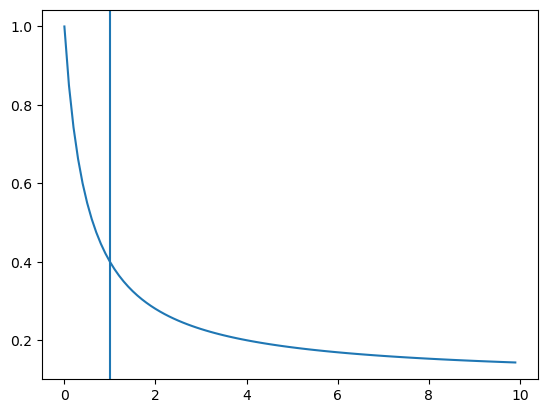

In [2]:
k10=1
k1sat=0.1
s1=0.5
k1vals=[]
avals=np.arange(0,10,0.1)
for a in avals:
    Hill1=(a)/(s1+a)
    k1=k10+(k1sat-k10)*Hill1
    k1vals.append(k1)
plt.plot(avals,k1vals)
plt.axvline(x=1)
    

10.0


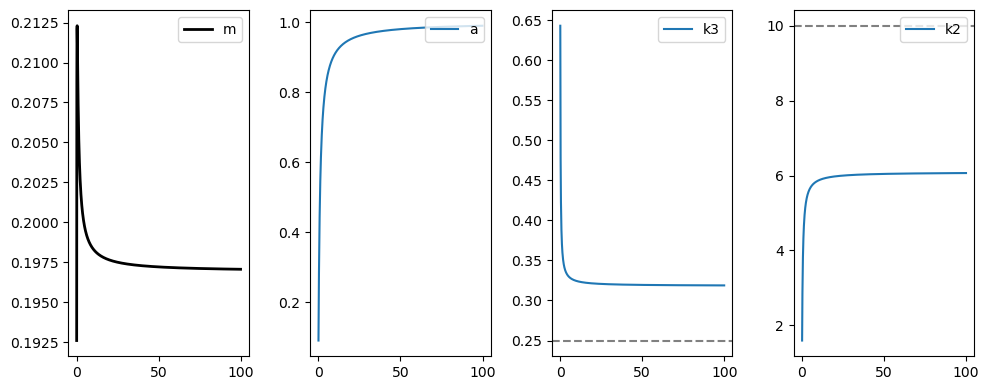

In [19]:
#doublecheck that non-monotonicity can also arise from effects on k2 and k3 (effects not involving k1)


k4=2
Kx=1

k1=0.75

k20=0.5
k2sat=k20*20
print(k2sat)
s2=0.7
n2=1

k30=1
k3sat=k30*0.25
s1=0.1
n1=1



pars=[k1,k20,k30,k4,Kx,s1,n1,k3sat,s2,n2,k2sat]

xvals=np.arange(0.1,100,0.1)
mvals=np.zeros_like(xvals)
occupancies=np.zeros_like(xvals)
k3s=np.zeros_like(xvals)
k2s=np.zeros_like(xvals)
for i in range(len(xvals)):
    x=xvals[i]
    m,a,k2,k3=f2(x,pars)
    mvals[i]=m
    occupancies[i]=a
    k2s[i]=k2
    k3s[i]=k3

fig,axes=plt.subplots(1,4,figsize=(10,4))
ax=axes[0]
ax.plot(xvals,mvals,label="m",linewidth=2,color="k")
ax=axes[1]
ax.plot(xvals,occupancies,label="a")
ax=axes[2]
ax.plot(xvals,k3s,label="k3")
ax.axhline(y=k3sat,linestyle="--",color="gray")
ax=axes[3]
ax.plot(xvals,k2s,label="k2")
ax.axhline(y=k2sat,linestyle="--",color="gray")
for ax in axes:
    ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

0.5


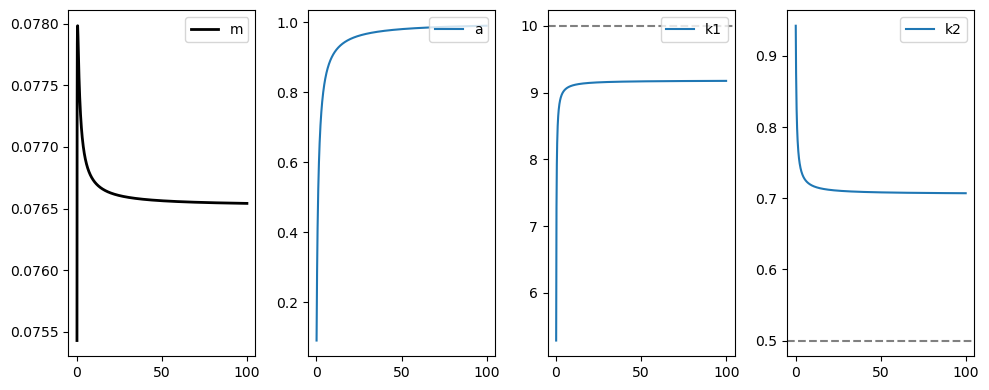

In [5]:
#Just with saturation in the relationship between occupancy and effect on rate is enough 

k3=0.1
k4=10
Kx=1

k10=1
k1sat=k10*10
s1=0.1
n1=1

k20=1
k2sat=k20*0.5
print(k2sat)
s2=0.7
n2=1

pars=[k10,k20,k3,k4,Kx,s1,n1,k1sat,s2,n2,k2sat]

xvals=np.arange(0.1,100,0.1)
mvals=np.zeros_like(xvals)
occupancies=np.zeros_like(xvals)
k1s=np.zeros_like(xvals)
k2s=np.zeros_like(xvals)
for i in range(len(xvals)):
    x=xvals[i]
    m,a,k1,k2=f1(x,pars)
    mvals[i]=m
    occupancies[i]=a
    k1s[i]=k1
    k2s[i]=k2

fig,axes=plt.subplots(1,4,figsize=(10,4))
ax=axes[0]
ax.plot(xvals,mvals,label="m",linewidth=2,color="k")
ax=axes[1]
ax.plot(xvals,occupancies,label="a")
ax=axes[2]
ax.plot(xvals,k1s,label="k1")
ax.axhline(y=k1sat,linestyle="--",color="gray")
ax=axes[3]
ax.plot(xvals,k2s,label="k2")
ax.axhline(y=k2sat,linestyle="--",color="gray")
for ax in axes:
    ax.legend(loc="upper right")
plt.tight_layout()
plt.show()
    

0.01


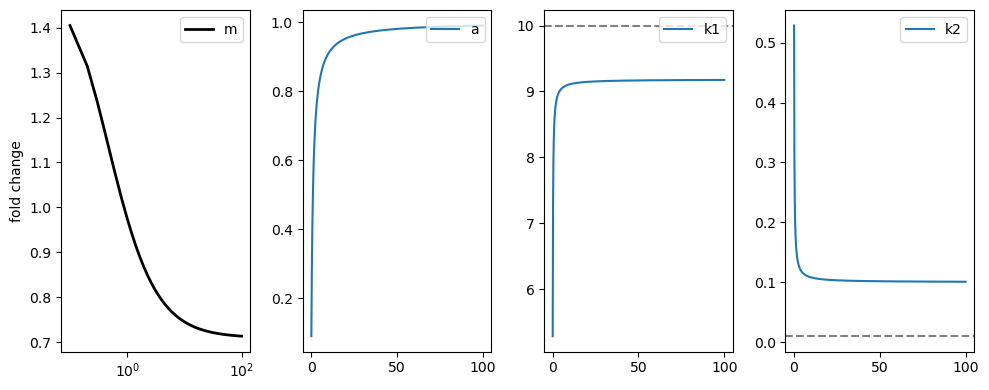

In [7]:
#Just with saturation in the relationship between occupancy and effect on rate is enough  (n1=n2=1)

k3=0.1
k4=10
Kx=1

k10=1
k1sat=k10*10
s1=0.1
n1=1

k20=1
k2sat=k20*0.01
print(k2sat)
s2=0.1
n2=1

pars=[k10,k20,k3,k4,Kx,s1,n1,k1sat,s2,n2,k2sat]

xvals=np.arange(0.1,100,0.1)
mvals=np.zeros_like(xvals)
occupancies=np.zeros_like(xvals)
k1s=np.zeros_like(xvals)
k2s=np.zeros_like(xvals)
m0=f1(0,pars)[0]
for i in range(len(xvals)):
    x=xvals[i]
    m,a,k1,k2=f1(x,pars)
    mvals[i]=m
    occupancies[i]=a
    k1s[i]=k1
    k2s[i]=k2

fig,axes=plt.subplots(1,4,figsize=(10,4))
ax=axes[0]
ax.plot(xvals,mvals/m0,label="m",linewidth=2,color="k")
ax.set_ylabel("fold change")
ax.set_xscale("log")
ax=axes[1]
ax.plot(xvals,occupancies,label="a")
ax=axes[2]
ax.plot(xvals,k1s,label="k1")
ax.axhline(y=k1sat,linestyle="--",color="gray")
ax=axes[3]
ax.plot(xvals,k2s,label="k2")
ax.axhline(y=k2sat,linestyle="--",color="gray")
for ax in axes:
    ax.legend(loc="upper right")
plt.tight_layout()
plt.show()
    